# Foundations of Machine learning

Problem Set 4

Emily Fu

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sys  
import os
from pathlib import Path

# importing my code from another file
import importlib
sys.path.insert(0, str(Path.cwd()))

import functions_A4
from functions_A4 import evaluate_bandit, calculate_replication, bernoulli_bandit

In [10]:
# set parameters

# set seed
seed = 420

# generate thetas with k = 2 and theta_1 = 0.5
thetas_twoarm = []
# fill in theta_2 from 0.1 to 0.9 in increments of 0.1
for theta_2 in np.arange(0.1, 1.0, 0.1):
    thetas_twoarm.append([0.5, theta_2])

# showing function usage
theta = [0.2, 0.5, 0.8]
T = 100

# replications
R = 10000

1. In this problem, you are asked to simulate data for a Bernoulli bandit problem, where 

$D_t \in \{1,...,k\}$, $Y_t = Y^{D}_t$ , $Y^{d}_t ∼ \text{Ber}( \theta_{d} )$,

and treatment is assigned using Thompson sampling with a uniform prior, $(\theta_{1},...,\theta_{k}) ∼ U([0,1]^k)$. Recall that Thompson sampling assigns 

$ D_t = \text{argmax}_d \: \hat{\theta}^{d}_t $, 

where $\hat{\theta}_t$ is a draw from the posterior after period $t−1$.

a) Set up a function which accepts a sample size $T$ and a k-vector $(\theta_{1},...,\theta_{k})$ as its arguments, and returns a history $(D_t,Y_t)^T_{t=1}$ generated based on the Bernoulli bandit model and Thompson sampling

I'm writing this in the VSCode Jupyter extension and can't get parallel computing to work in its actual UI, so I've made up a Python file for all my functions and am pasting the below here as plaintext:

    # question 1a, question 2a
    def bernoulli_bandit(T, theta, seed=420, M=1000, exploration=False):
        # for generating from distributions
        rng = np.random.default_rng(seed)

        # get the amount of treatments from their true expected outcomes
        k = len(theta)
        
        # initialise arrays to store the selected treatments and observed outcomes
        D_t = np.zeros(T, dtype=int)
        Y_t = np.zeros(T)
        
        # the posterior for theta_d at time t + 1 is a Beta distribution with parameters
        # start with uniform prior over theta on [0, 1]^k
        # 1 + number of successes
        alpha = np.ones(k)
        # 1 + number of failures
        beta = np.ones(k)
        
        for t in range(T):
            # case for exploration sampling
            if exploration:
                # sample from the Beta distribution for each arm
                draws = rng.beta(alpha, beta, size=(M, k))
                # but now need to actually get a distribution i need to like approximate it
                # find which arm is best in each simulated world
                best_arms = np.argmax(draws, axis=1)
                # count how often each treatmnet is the largest, use those frequencies as an estimate for p
                p_t = np.bincount(best_arms, minlength=k) / M
                # print(p_t)

                # calculate q_t for exploration sampling
                weights = p_t * (1 - p_t)
                denom = weights.sum()
                
                # when it's got a weight of one on one treatment 
                # (very certain that one treatment is best)
                if denom == 0:
                    q_t = np.ones(k) / k   # fallback to uniform
                else:
                    q_t = weights / denom
                # print(weights)
                # print(weights.sum())

                # choose with probabilities given by q_t instead of directly from the beta distribution
                action = rng.choice(k, p=q_t)
                D_t[t] = action
            # thompson sampling
            else:
                # sample from the Beta distribution for each arm
                samples = rng.beta(alpha, beta)
                # print(samples)
                
                # find which treatment gave the highest sample and select that treatment
                action = np.argmax(samples)
                # store which treatment this corresponds to
                D_t[t] = action
            
            # assume that outcome follows a Bernoulli distribution with parameter theta[action]
            outcome = rng.binomial(1, theta[action])
            Y_t[t] = outcome
            # print(outcome)
            
            # update alpha and beta parameters of posterior based on the observed outcome
            if outcome == 1:
                # another success
                alpha[action] += outcome
            else:
                # not success
                beta[action] += 1 - outcome
        
            # mean for each arm after period T (beta distribution expected value)
            posterior_means = alpha / (alpha + beta)

            # treatment with highest posterior mean at time T
            d_highest_posterior_mean = np.argmax(posterior_means)
                
        return D_t, Y_t, d_highest_posterior_mean

In [12]:
# example use of bernoulli_bandit for thompson samplin

D_t, Y_t, d_highest_posterior_mean = bernoulli_bandit(T, theta, seed=seed)

# see that the algorithm is assigning treatment with higher theta more often over time
print(f'treatment history: {D_t}')
print(f'Treatment with the highest posterior mean at time T: {d_highest_posterior_mean}')

treatment history: [1 2 1 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 1 2 2 2 2 2 2 2 2 2 2 2 2 1 2]
Treatment with the highest posterior mean at time T: 2


b) Write a second function which takes the same arguments, plus a number of replications $R$, and evaluates the first function $R$ times (using parallel computing; for instance the `future` package). This function should return 4 vectors of length $T$: The averages of $Y_t$, $\theta^{D_t}$, ${1(D_t = \text{argmax}_d \: \theta_{d})}$, and $\text{max} \: \theta_{d} − \theta^{D_t} $, for each time period $t$.

Splitting this into one kind-of-lambda function and one that does the parallel computing (from what I've found, there are multiple parallel computing options for Python and I've used [`dask`](https://docs.dask.org/en/stable/)):

    # question 1b
    def calculate_replication(T, theta, seed=420):
        # format of theta
        theta = np.asarray(theta, dtype=float)

        # get the actions and outcomes for T time steps
        D_t, Y_t = bernoulli_bandit_thompson(T, theta, seed=seed)

        # best treatment and its theta value
        best_arm = np.argmax(theta)
        best_theta = np.max(theta)
        
        # get the theta value of the selected arm at each time step
        theta_Dt = theta[D_t]
        # how many times the optimal treatment was selected at each time step
        optimal_indicator = (D_t == best_arm).astype(float)
        # calculate regret at each time step
        regret_t = best_theta - theta_Dt

        return Y_t.astype(float), theta_Dt, optimal_indicator, regret_t

    # question 1b
    def evaluate_bandit(T, theta, R, seed=420):
        # format of theta
        theta = np.asarray(theta, dtype=float)

        # actually do it for the R replications
        tasks = [delayed(calculate_replication)(T, theta, seed + r) for r in range(R)]

        # compute the results in parallel using dask
        results = compute(*tasks, scheduler='threads')

        # aggregate results across replications
        Y_all = np.array([res[0] for res in results])
        thetaDt_all = np.array([res[1] for res in results])
        opt_all = np.array([res[2] for res in results])
        regret_all = np.array([res[3] for res in results])

        # averagevalues of Y_t, theta_Dt, optimal indicator, and regret_t across the R replications
        avg_Y_t = Y_all.mean(axis=0)
        avg_theta_Dt = thetaDt_all.mean(axis=0)
        avg_optimal = opt_all.mean(axis=0)
        avg_regret_t = regret_all.mean(axis=0)

        # cumulative average regret and average of cumulative average regret across the R replications
        avg_cum_regret_t = np.cumsum(avg_regret_t)
        avg_cumavg_regret_t = avg_cum_regret_t / np.arange(1, T + 1)

        return avg_Y_t, avg_theta_Dt, avg_optimal, avg_regret_t, avg_cum_regret_t, avg_cumavg_regret_t


c) Pick a fixed vector of parameters $(\theta_{1},...,\theta_{k})$ and a time horizon $T$ and use the second function to plot the average (across replications) of cumulative average regret

$$\frac{1}{T} \sum_{1 \leq t \leq T} [(\text{max}_{d} \: \theta^{d}) - \theta^{D_t}]$$

as a function of T, using a large number of replications $R$ (such as $R = 10.000$). 

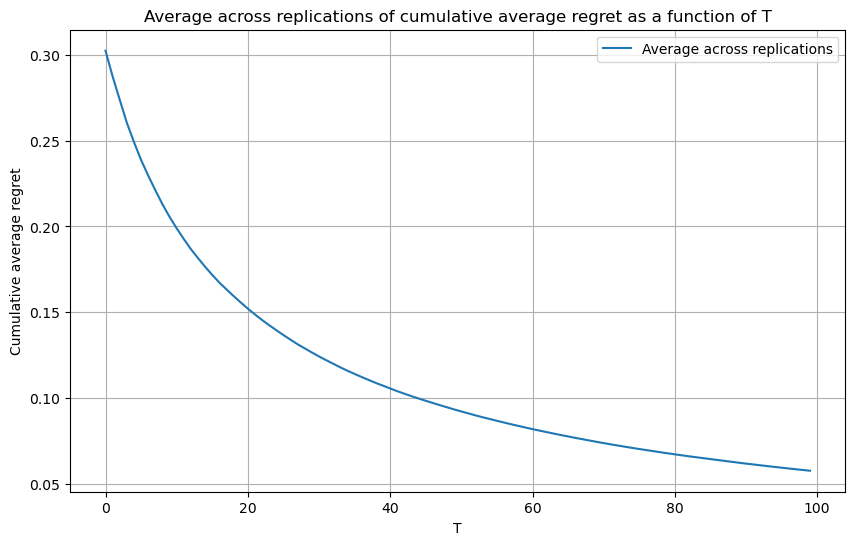

In [4]:
avg_cumavg_regret = evaluate_bandit(T, theta, R, seed=seed)[-1]

# plot average (across replications) of cumulative average regret as a function of T
plt.figure(figsize=(10, 6))
plt.plot(avg_cumavg_regret, label='Average across replications')
plt.xlabel('T')
plt.ylabel('Cumulative average regret')
plt.title('Average across replications of cumulative average regret as a function of T')
plt.legend()
plt.grid()
plt.show()


Repeat this for several different choices of $(\theta_{1},...,\theta_{k})$. 

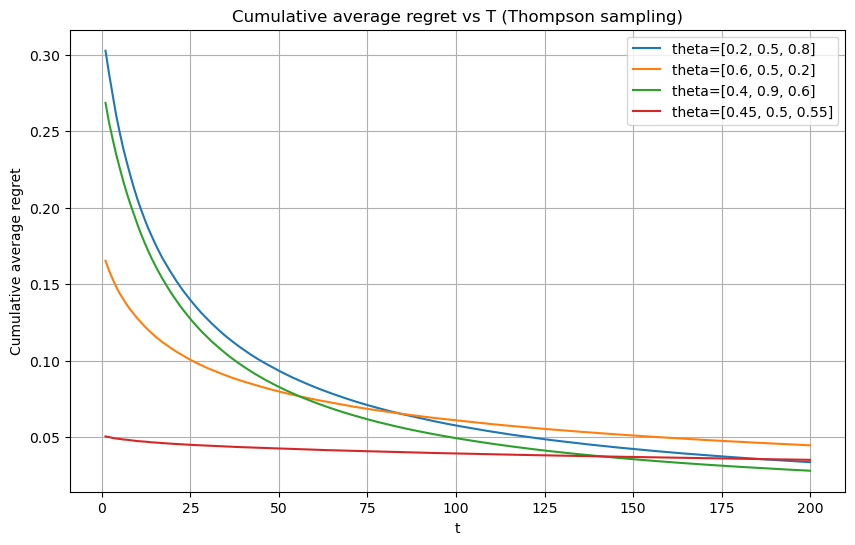

In [5]:
# some thetas
thetas = [[0.2, 0.5, 0.8], [0.6, 0.5, 0.2], [0.4, 0.9, 0.6], [0.45, 0.5, 0.55]]

T = 200
R = 10000

plt.figure(figsize=(10, 6))
# line up the times with the periods
x = np.arange(1, T + 1)

# calculate cumulative average regret for all thetas and plot them on the same graph
for i, theta in enumerate(thetas):
    avg_cumavg_regret = evaluate_bandit(T, theta, R, seed=seed)[-1]
    plt.plot(x, avg_cumavg_regret, label=f'theta={theta}')

plt.xlabel('t')
plt.ylabel('Cumulative average regret')
plt.title('Cumulative average regret vs T (Thompson sampling)')
plt.legend()
plt.grid(True)
plt.show()

How does the result relate to the theoretical regret rate bound discussed in class, and to Agrawal and Goyal (2012)?

The result from the slides says that expected regret (difference to optimal policy) goes to 0 at a rate of $\text{O}(\log(T)/T)$ for the UCB algorithm. For large $T$, similar upper bounds on $\mathop{\mathbb{E}}[T_{d}^{T}]$ (the amount of times the treatment is used) for the UCB algorithm hold for Thompson sampling. Then, Theorem 2 from Agrawal and Goyal (2012) shows that the Thompson Sampling algorithm also has logarithmic decay in expected regret

For the N-armed stochastic bandit problem, Thompson sampling has expected regret

$$\mathop{\mathbb{E}}[R(T)] \leq \text{O} ((\sum_{a = 2}^{N} \frac{1}{\Delta^{2}_{a}})^2 (\ln T))$$

They're using $a$ to denote each treatment out of $N$ total treatments, and $\mathop{\mathbb{E}}[R(T)]$ would be expected cumulative regret. This means they showed that cumulative regret grows logarithmically in time, so if I divide by $T$, I get the same $\text{O}(\log(T)/T)$ rate for Thompson Sampling.

Here, the thing I'm plotting is cumulative regret divided by time across all my replications, which is the sample version of how expected regret $R_T$ is defined in the slides and it is decreasing in $T$ towards zero, but decreases slower with higher $T$. The point of this is that as you get more history, you learn with the Thompson sampling algorithm which treatment is more likely to succeed. Then, cumulative regret grows slowly and its average will go to zero. Every time we were observing our outcome and updating the posterior, we were increasing the parameters in the beta distribution so that the more successful treatments are more likely to be chosen again which makes average regret decrease. However, once the regret is already small and the probability that Thompson sampling picks the wrong treatment becomes very small, cumulative average regret will decrease by less. I chose a few $\theta$ s with different expected outcomes, and the ones with treatments that vary in expected outcome by a lot have higher average regret as T is small but that decay faster. One of my choices was $\theta = [0.45, 0.5, 0.55]$, which is much flatter than the others since the expeced outcomes are close to each other and so regret is always small and I think it wouldn't learn which one is the best treatment as fast.

d) Now let $k = 2$, fix $\theta_{1} = 0.5$ and $T = 200$. Plot cumulative average regret for $T$ as a function of $\theta_{2}$, for $\theta_{2} \in [0,1]$. Do the same for the share of observations assigned to the optimal treatment.

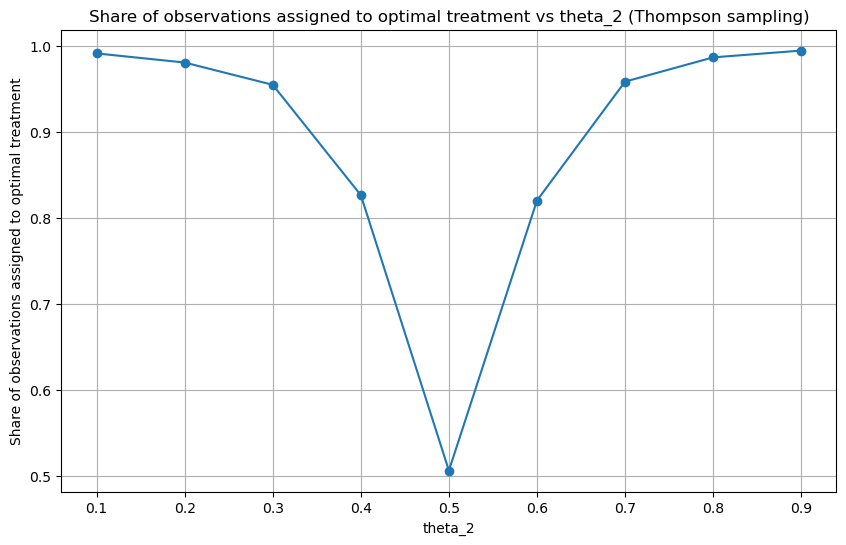

In [6]:
# plot share of observations assigned to the optimal treatment as a function of theta_2
plt.figure(figsize=(10, 6))
optimal_shares = []
for theta in thetas_twoarm:
    # get average optimal treatment assignment over time across replications for this theta
    avg_optimal = evaluate_bandit(T, theta, R, seed=seed)[2]
    ## share of observations assigned to optimal treatment at the end of T
    optimal_shares.append(avg_optimal[-1])  

plt.plot(np.arange(0.1, 1.0, 0.1), optimal_shares, marker='o')
plt.xlabel('theta_2')
plt.ylabel('Share of observations assigned to optimal treatment')
plt.title('Share of observations assigned to optimal treatment vs theta_2 (Thompson sampling)')
plt.grid()
plt.show()

In [ ]:
# plot cumulative average regret for T as a function of theta_2


How does the result relate to the local-to-zero asymptotics discussed in class, and to Figure 3 in Wager and Xu (2021)?

See that share of observations assigned to optimal treatment is greater when $\theta_{2}$ is more different from $\theta_{1}$ (i.e. when it's easier to distinguish which treatment is better)

2. In this problem, we will again consider the Bernoulli bandit, and compare Thompson sampling to exploration sampling, as discussed in Kasy and Sautmann (2021).

Notes from Kasy and Sautmann (2021):

In Thompson sampling, the probability that a treatment $d$ is assigned to a given experimental unit arriving at $t$ is equal to the posterior probability $p^{d}_{t}$ (given outcomes up to $t−1$) that this treatment is in fact optimal.

Based on Thompson sampling, we propose a modified treatment assignment algorithm which we call exploration sampling. It replaces the Thompson assignment shares $($p^{1}_{t}, ..., $p^{k}_{t})$ with the following transformed shares:

$$q^{d}_{t} = S_t p^{d}_{t} (1 − p^{d}_{t}),$$

$$S_t = \frac{1}{\sum_{d} p^{d}_{t} (1 - p^{d}_{t})}$$

Exploration sampling would arise if we used Thompson sampling but never assigned the same treatment twice in a row, thus improving power for comparisons of relevant alternatives. This modification shifts weight away from the best performing option to its close competitors.

Our key result, Theorem 1, shows that exploration sampling achieves the best possible exponential rate of convergence, subject to the constraint that, in the limit, half the observations are assigned to the best treatment. It achieves in particular a better exponential rate than non-adaptive assignment, and converges much faster than Thompson sampling, which only converges polynomially.

a) Create a modified version of the first function from problem 1, where instead of Thompson sampling treatment is assigned using exploration sampling. Let this function additionally return the treatment $d^{*}_{T}$ with the highest posterior mean.

    # question 2a
    def bernoulli_bandit_exploration(T, theta, seed=420, M=2000):
        # for generating from distributions
        rng = np.random.default_rng(seed)
        
        # get the amount of treatments from their true expected outcomes
        k = len(theta)

        # initialise arrays to store the selected treatments and observed outcomes
        D_t = np.zeros(T, dtype=int)
        Y_t = np.zeros(T)

        # the posterior for theta_d at time t + 1 is a Beta distribution with parameters
        # start with uniform prior over theta on [0, 1]^k
        # 1 + number of successes
        alpha = np.ones(k)
        # 1 + number of failures
        beta = np.ones(k)

        for t in range(T):
            # sample from the Beta distribution for each arm
            draws = rng.beta(alpha, beta, size=(M, k))
            # but now need to actually get a distribution i need to like approximate it
            # find which arm is best in each simulated world
            best_arms = np.argmax(draws, axis=1)
            # count how often each treatmnet is the largest, use those frequencies as an estimate for p
            p_t = np.bincount(best_arms, minlength=k) / M
            # print(p_t)

            # calculate q_t for exploration sampling
            weights = p_t * (1 - p_t)
            denom = weights.sum()
            
            # when it's got a weight of one on one treatment 
            # (very certain that one treatment is best)
            if denom == 0:
                q_t = np.ones(k) / k   # fallback to uniform
            else:
                q_t = weights / denom
            # print(weights)
            # print(weights.sum())

            # choose with probabilities given by q_t instead of directly from the beta distribution
            action = rng.choice(k, p=q_t)
            D_t[t] = action

            # assume that outcome follows a Bernoulli distribution with parameter theta[action]
            outcome = rng.binomial(1, theta[action])
            Y_t[t] = outcome
            # print(outcome)

            # update alpha and beta parameters of posterior based on the observed outcome
            if outcome == 1:
                # another success
                alpha[action] += outcome
            else:
                # not success
                beta[action] += 1 - outcome

        # mean for each arm after period T (beta distribution expected value)
        posterior_means = alpha / (alpha + beta)

        # treatment with highest posterior mean at time T
        d_highest_posterior_mean = np.argmax(posterior_means)

        return D_t, Y_t, d_highest_posterior_mean


In [13]:
# example use of bernoulli_bandit_exploration

D_t, Y_t, d_highest_posterior_mean = bernoulli_bandit(T, theta, seed=seed, exploration=True)

print(f'treatment history: {D_t}')

# like i guess it's exploring more
print(f'Treatment with the highest posterior mean at time T: {d_highest_posterior_mean}')

treatment history: [1 1 1 1 0 0 1 1 1 2 1 2 1 1 2 1 1 1 0 1 1 2 2 0 1 2 1 2 1 0 1 2 0 0 2 0 2
 0 1 0 2 1 2 2 2 1 2 2 2 2 1 1 1 1 1 1 0 1 2 2 0 1 2 2 1 2 1 2 1 1 2 2 2 1
 2 2 0 1 2 2 0 0 1 1 2 0 2 0 1 1 2 2 2 2 2 1 1 1 1 1]
Treatment with the highest posterior mean at time T: 2


b) Create a modified version of the second function from problem 1, again replacing Thompson sampling by exploration sampling. Let this function additionally return the average across replications of policy regret 

$$(\text{max}_d \theta^{d}) - \theta^{d^{*}_{T}}$$

and the probability of choosing the best arm, $P(d^{*}_{T} = \text{argmax}_d \theta_{d})$. Edit the second function from problem 1 to do the same for Thompson sampling